In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Feature Analysis

In [2]:
pd.read_csv("ml-32m/movies.csv")

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
87580,292731,The Monroy Affaire (2022),Drama
87581,292737,Shelter in Solitude (2023),Comedy|Drama
87582,292753,Orca (2023),Drama
87583,292755,The Angry Breed (1968),Drama


In [3]:
pd.read_csv("ml-32m/ratings.csv")

,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858
...,...,...,...,...
32000199,200948,79702,4.5,1294412589
32000200,200948,79796,1.0,1287216292
32000201,200948,80350,0.5,1294412671
32000202,200948,80463,3.5,1350423800


In [4]:
def load_data():
    movies = pd.read_csv(
        "ml-32m/movies.csv",
        usecols=["movieId", "title", "genres"],
        dtype={"movieId": "int32", "title": "string", "genres": "string"},
    )
    ratings = pd.read_csv(
        "ml-32m/ratings.csv",
        usecols=["userId", "movieId", "rating"],
        dtype={"userId": "int32", "movieId": "int32", "rating": "float32"},
    )
    return movies, ratings

movies, ratings = load_data()

print(f"Movies: {len(movies):,}")
print(f"Ratings: {len(ratings):,}")
print(f"Users: {ratings['userId'].nunique():,}")
print(f"Average rating: {ratings['rating'].mean():.3f}")

Movies: 87,585
Ratings: 32,000,204
Users: 200,948
Average rating: 3.540


,rating,count,percent
0,0.5,525132,1.641027
1,1.0,946675,2.958341
2,1.5,531063,1.659561
3,2.0,2028622,6.339403
4,2.5,1685386,5.266798
5,3.0,6054990,18.921723
6,3.5,4290105,13.406493
7,4.0,8367654,26.148752
8,4.5,2974000,9.293691
9,5.0,4596577,14.364212


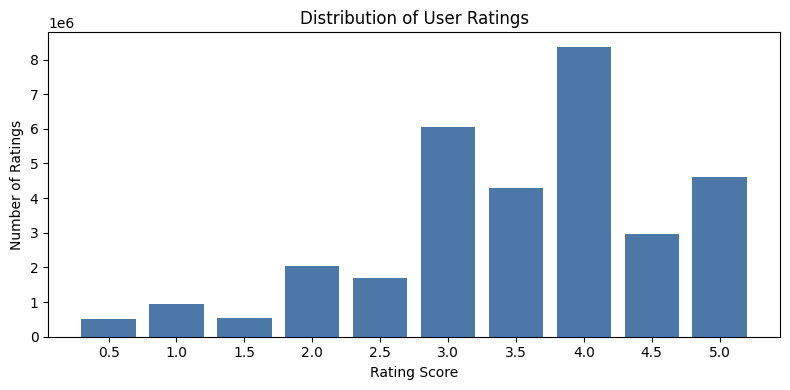

Most common rating: 4.0


In [5]:
rating_distribution = (
    ratings["rating"]
    .value_counts()
    .sort_index()
    .rename_axis("rating")
    .reset_index(name="count")
)
rating_distribution["percent"] = 100 * rating_distribution["count"] / rating_distribution["count"].sum()

display(rating_distribution)

plt.figure(figsize=(8, 4))
plt.bar(rating_distribution["rating"], rating_distribution["count"], width=0.4, color="#4C78A8")
plt.title("Distribution of User Ratings")
plt.xlabel("Rating Score")
plt.ylabel("Number of Ratings")
plt.xticks(rating_distribution["rating"])
plt.tight_layout()
plt.show()

most_common_rating = rating_distribution.loc[rating_distribution["count"].idxmax(), "rating"]
print(f"Most common rating: {most_common_rating}")

,movie_count,mean_genre_rating,median_genre_rating,total_ratings
genre,,,,
Film-Noir,117,3.707,3.720,299244
Documentary,547,3.648,3.720,351782
War,495,3.538,3.586,1570057
Drama,5772,3.452,3.511,13644046
Western,222,3.397,3.440,583350
Animation,703,3.372,3.412,2163337
Romance,1919,3.358,3.416,5430206
Crime,1469,3.354,3.411,5304842
Musical,404,3.354,3.451,1144397


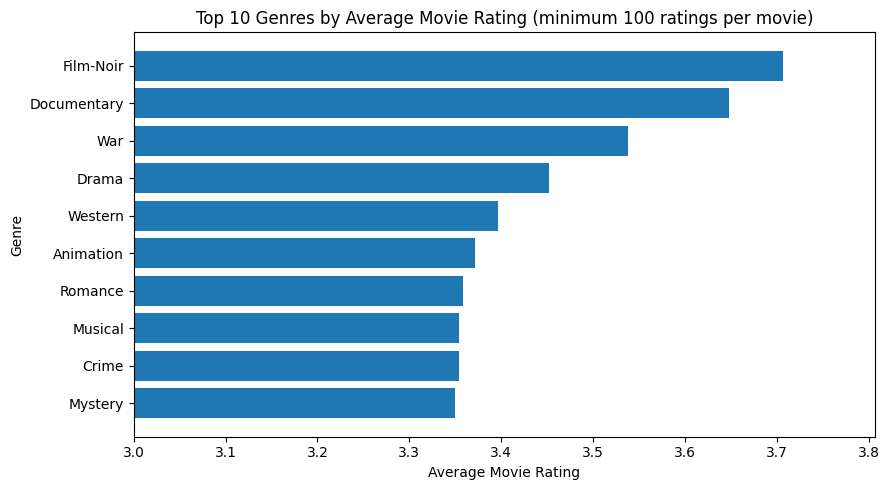

In [6]:
def build_movie_rating_stats(ratings_df):
    movie_rating_stats = (
        ratings_df.groupby("movieId")
        .agg(
            rating_count=("rating", "size"),
            average_rating=("rating", "mean"),
        )
        .reset_index()
    )
    return movie_rating_stats

def explode_genres(movies_df):
    genre_rows = movies_df.loc[movies_df["genres"] != "(no genres listed)", ["movieId", "genres"]].copy()
    genre_rows["genre"] = genre_rows["genres"].str.split("|")
    genre_rows = genre_rows.explode("genre").drop(columns="genres")
    return genre_rows

movie_rating_stats = build_movie_rating_stats(ratings)
genre_rows = explode_genres(movies)
movies_with_stats = genre_rows.merge(movie_rating_stats, on="movieId", how="inner")

min_ratings = 100
genre_summary = (
    movies_with_stats[movies_with_stats["rating_count"] >= min_ratings]
    .groupby("genre")
    .agg(
        movie_count=("movieId", "nunique"),
        mean_genre_rating=("average_rating", "mean"),
        median_genre_rating=("average_rating", "median"),
        total_ratings=("rating_count", "sum"),
    )
    .sort_values("mean_genre_rating", ascending=False)
    .round(3)
)

display(genre_summary)

top_genres = genre_summary.head(10).sort_values("mean_genre_rating")

plt.figure(figsize=(9, 5))
plt.barh(top_genres.index, top_genres["mean_genre_rating"])
plt.title(f"Top 10 Genres by Average Movie Rating (minimum {min_ratings} ratings per movie)")
plt.xlabel("Average Movie Rating")
plt.ylabel("Genre")
plt.xlim(3.0, top_genres["mean_genre_rating"].max() + 0.1)
plt.tight_layout()
plt.show()

Movie popularity summary


count     84432.000000
mean        379.005638
std        2592.439791
min           1.000000
25%           2.000000
50%           5.000000
75%          25.000000
max      102929.000000
Name: rating_count, dtype: float64

Movies with at least 10 ratings: 31,961
Movies with at least 100 ratings: 12,191
Movies with at least 1000 ratings: 4,397


,title,rating_count,average_rating
314,"Shawshank Redemption, The (1994)",102929,4.404614
351,Forrest Gump (1994),100296,4.052744
292,Pulp Fiction (1994),98409,4.196969
2480,"Matrix, The (1999)",93808,4.156436
585,"Silence of the Lambs, The (1991)",90330,4.148367
257,Star Wars: Episode IV - A New Hope (1977),85010,4.099823
2867,Fight Club (1999),77332,4.228780
475,Jurassic Park (1993),75233,3.698623
522,Schindler's List (1993),73849,4.236990
4888,"Lord of the Rings: The Fellowship of the Ring,...",73122,4.092134


Histogram shown up to the 99th percentile: 249 ratings


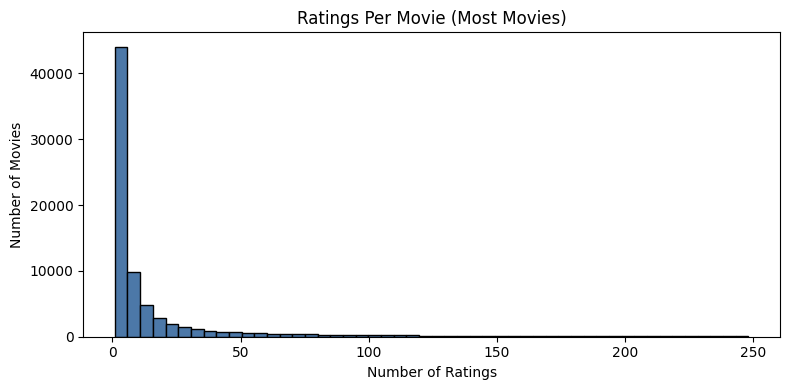

In [7]:
movie_activity = (
    ratings.groupby("movieId")
    .agg(
        rating_count=("rating", "size"),
        average_rating=("rating", "mean")
    )
    .reset_index()
)

print("Movie popularity summary")
display(movie_activity["rating_count"].describe())

print(f"Movies with at least 10 ratings: {(movie_activity['rating_count'] >= 10).sum():,}")
print(f"Movies with at least 100 ratings: {(movie_activity['rating_count'] >= 100).sum():,}")
print(f"Movies with at least 1000 ratings: {(movie_activity['rating_count'] >= 1000).sum():,}")

top_movies = movie_activity.merge(movies[["movieId", "title"]], on="movieId", how="left")
top_movies = top_movies.sort_values("rating_count", ascending=False).head(10)
display(top_movies[["title", "rating_count", "average_rating"]])

plot_limit = movie_activity["rating_count"].quantile(0.9)

print(f"Histogram shown up to the 99th percentile: {plot_limit:.0f} ratings")

plt.figure(figsize=(8, 4))
plt.hist(
    movie_activity.loc[movie_activity["rating_count"] <= plot_limit, "rating_count"],
    bins=50,
    color="#4C78A8",
    edgecolor="black"
)
plt.title("Ratings Per Movie (Most Movies)")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

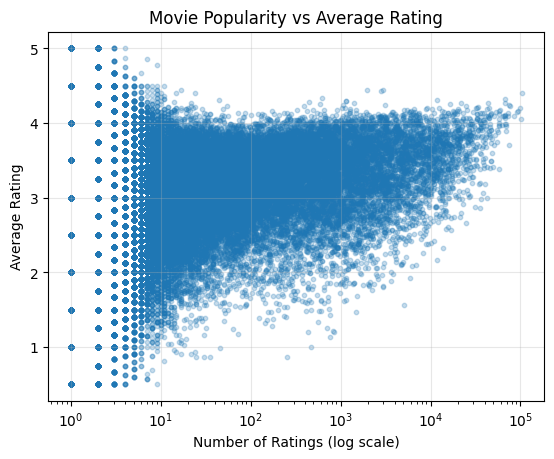

In [8]:
# Visualization: relationship between movie popularity and average rating
plt.figure()
plt.scatter(
    movie_activity["rating_count"],
    movie_activity["average_rating"],
    alpha=0.25,
    s=10
)

plt.xscale("log")
plt.title("Movie Popularity vs Average Rating")
plt.xlabel("Number of Ratings (log scale)")
plt.ylabel("Average Rating")
plt.grid(True, alpha=0.3)
plt.show()

User activity summary


count    200948.000000
mean        159.246193
std         282.025462
min          20.000000
25%          36.000000
50%          73.000000
75%         167.000000
max       33332.000000
Name: rating_count, dtype: float64

Users with at least 50 ratings: 128,344
Users with at least 100 ratings: 80,675
Users with at least 500 ratings: 12,603


,userId,rating_count,average_rating_given
175324,175325,33332,3.077808
17034,17035,9577,2.567819
55652,55653,9178,3.280290
123464,123465,9044,2.528859
171794,171795,9016,3.181954
10201,10202,7748,3.411655
198514,198515,7594,2.822755
49304,49305,7488,3.208868
22743,22744,7372,2.640193
7857,7858,7322,1.549850


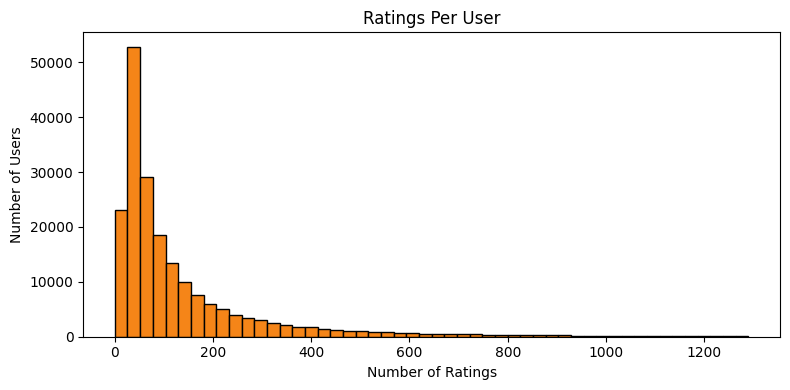

In [9]:
user_activity = (
    ratings.groupby("userId")
    .agg(
        rating_count=("rating", "size"),
        average_rating_given=("rating", "mean")
    )
    .reset_index()
)

print("User activity summary")
display(user_activity["rating_count"].describe())

print(f"Users with at least 50 ratings: {(user_activity['rating_count'] >= 50).sum():,}")
print(f"Users with at least 100 ratings: {(user_activity['rating_count'] >= 100).sum():,}")
print(f"Users with at least 500 ratings: {(user_activity['rating_count'] >= 500).sum():,}")

top_users = user_activity.sort_values("rating_count", ascending=False).head(10)
display(top_users)

plot_limit = user_activity["rating_count"].quantile(0.99)

plt.figure(figsize=(8, 4))
plt.hist(
    user_activity["rating_count"],
    bins=50,
    range=(0, plot_limit),
    color="#F58518",
    edgecolor="black"
)
plt.title("Ratings Per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()

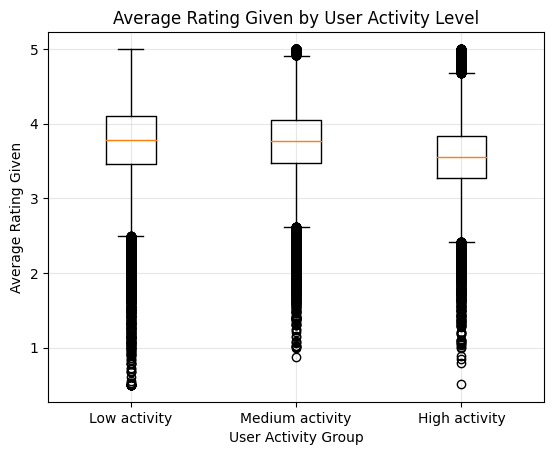

In [10]:
# compare average ratings given by user activity level
user_activity["activity_group"] = pd.cut(
    user_activity["rating_count"],
    bins=[0, 50, 200, user_activity["rating_count"].max()],
    labels=["Low activity", "Medium activity", "High activity"]
)

grouped_ratings = [
    user_activity.loc[user_activity["activity_group"] == group, "average_rating_given"].dropna()
    for group in ["Low activity", "Medium activity", "High activity"]
]

plt.figure()
plt.boxplot(grouped_ratings, labels=["Low activity", "Medium activity", "High activity"])
plt.title("Average Rating Given by User Activity Level")
plt.xlabel("User Activity Group")
plt.ylabel("Average Rating Given")
plt.grid(True, alpha=0.3)
plt.show()

### What features?

Based on the anaylsis above for features we chose: userId, movieId, genres, and movie rating count. We selected userId and movieId because the recommendation task will depend on the interaction between users and specific movies. Our analysis showed that average ratings differ across genres even after filtering out movies with very few ratings, making genres a good choice. We also included movie rating count because the dataset is imbalanced, the median movie has only five ratings, while a small number of movies have very large number of ratings. This makes it a useful feature for measuring confidence and popularity. For an initial test, these features should perform well before attempting more complex feature engineering.

## Model Training

In [11]:
# chosen test size
sample_size = 300000
ratings_sample = ratings.sample(n=sample_size, random_state=42)

train = ratings_sample.sample(frac=0.8, random_state=42).copy()
test = ratings_sample.drop(train.index).copy()

print(f"Train rows: {len(train):,}")
print(f"Test rows: {len(test):,}")

Train rows: 240,000
Test rows: 60,000


In [12]:
# train simple model
global_mean = train["rating"].mean()

# movie statistics from training data only
movie_stats = train.groupby("movieId")["rating"].agg(["count", "sum"])
movie_stats.columns = ["movie_count", "movie_sum"]

# smoothed movie average uses rating_count as a confidence feature
alpha = 20
movie_stats["movie_smoothed"] = (movie_stats["movie_sum"] + alpha * global_mean) / (movie_stats["movie_count"] + alpha)
movie_stats["movie_bias"] = movie_stats["movie_smoothed"] - global_mean

# user statistics from training data only
user_stats = train.groupby("userId")["rating"].agg(["count", "sum"])
user_stats.columns = ["user_count", "user_sum"]
user_stats["user_smoothed"] = (user_stats["user_sum"] + alpha * global_mean) / (user_stats["user_count"] + alpha)
user_stats["user_bias"] = user_stats["user_smoothed"] - global_mean

# predictions
test = test.merge(movie_stats[["movie_smoothed", "movie_bias"]], left_on="movieId",
right_index=True, how="left")
test = test.merge(user_stats[["user_bias"]], left_on="userId", right_index=True,
how="left")

In [13]:
# model 1 is global mean baseline
test["pred_global"] = global_mean

# model 2 ismovie mean baseline
test["pred_movie"] = test["movie_smoothed"].fillna(global_mean)

# model 3 is user + movie bias model
test["pred_user_movie"] = (global_mean + test["movie_bias"].fillna(0) + test["user_bias"].fillna(0)).clip(0.5, 5.0)

# visualize results
def rmse(actual, predicted):
      return np.sqrt(np.mean((actual - predicted) ** 2))

def mae(actual, predicted):
  return np.mean(np.abs(actual - predicted))

results = pd.DataFrame([
  {
      "model": "Global mean baseline",
      "rmse": rmse(test["rating"], test["pred_global"]),
      "mae": mae(test["rating"], test["pred_global"]),
  },
  {
      "model": "Movie mean baseline",
      "rmse": rmse(test["rating"], test["pred_movie"]),
      "mae": mae(test["rating"], test["pred_movie"]),
  },
  {
      "model": "User + movie bias model",
      "rmse": rmse(test["rating"], test["pred_user_movie"]),
      "mae": mae(test["rating"], test["pred_user_movie"]),
  },
]).sort_values("rmse")

results

,model,rmse,mae
2,User + movie bias model,0.958403,0.740647
1,Movie mean baseline,0.988878,0.763102
0,Global mean baseline,1.060189,0.837402


### Model Types

The user + movie bias model performed better than both the simple baselines, this shows adding both user and movie specific rating tendencies improves accuracy. Still plenty of room to make better models.